<table align="center">
  <td align="center"><a target="_blank" href="https://colab.research.google.com/github/sherifmost/DeepLearning/blob/master/Labs/lab2/lab2.ipynb">
        <img src="http://introtodeeplearning.com/images/colab/colab.png?v2.0"  style="padding-bottom:5px;" />Run in Google Colab</a></td>
</table>

# Assignment 1: Multinominal Classification

![Multinominal Classification Network](https://github.com/KhaledElTahan/DeepLearning/blob/master/Labs/lab2/multinominal_classification_net.png?raw=1)

## 1.1 Problem Statement

In this assignment we will be addressing the task of multinominal classification of handwritten digits from the famous MNIST dataset.

The MNIST dataset consists of 60,000 training images and 10,000 test images.  Our classes are the digits 0-9.

You are required to build 2 models to solve this problem:
1. A simple model using fully connected layers.
2. A model using Convolutional Neural Network (CNN) before applying the simple model.

You should perform different experiments on the two models, observe the difference in **accuracy** and report them.

At the end you should perform **machine learning interpretability analysis** and report your observations.

## 1.2 Problem Details

### 1.2.1 Dataset Loading

#### Import Needed packages

In [24]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import random
from progressbar import progressbar


#### Load Dataset

In [25]:
mnist = tf.keras.datasets.mnist
(train_images, train_labels), (val_images, val_labels) = mnist.load_data()

train_images = np.expand_dims(train_images, axis=-1) / 255.
train_labels = np.int64(train_labels)

val_images = np.expand_dims(val_images, axis=-1) / 255.
val_labels = np.int64(val_labels)

#### Plot Dataset Sample

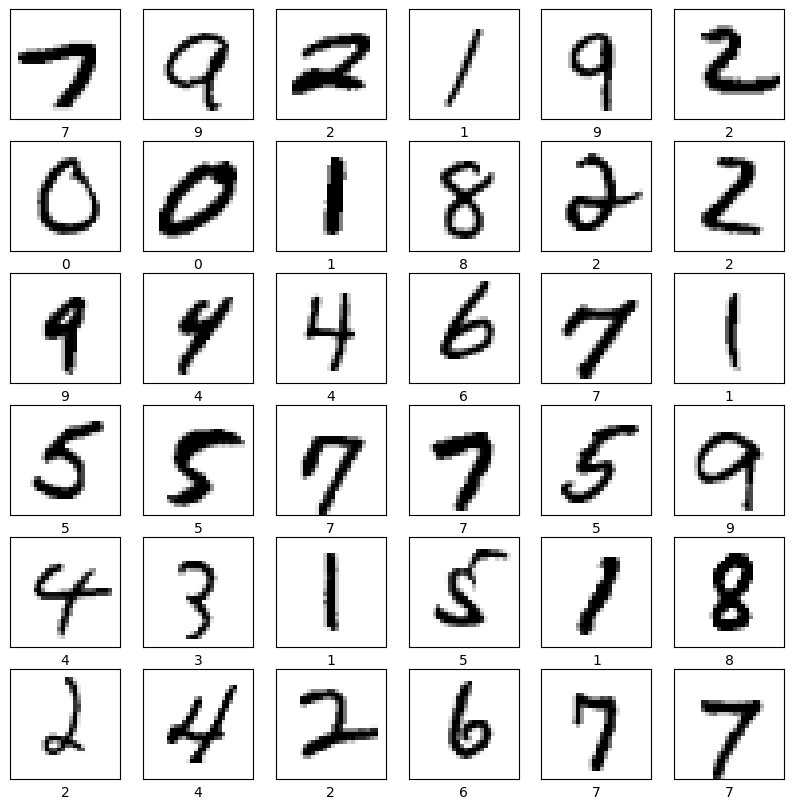

In [26]:
plt.figure(figsize=(10, 10))
random_inds = np.random.choice(60000, 36)
for i in range(36):
    plt.subplot(6, 6, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    image_ind = random_inds[i]
    plt.imshow(np.squeeze(train_images[image_ind]), cmap=plt.cm.binary)
    plt.xlabel(train_labels[image_ind])

### 1.2.2 Fully Connected Neural Network Solution

Build a neural network, using tf.keras, consisting of 2 fully connected layers and apply this to the digit classification task, Our network will ultimately output a probability distribution over the 10 digit classes (0-9).

![Two Layer Neural Network](https://github.com/KhaledElTahan/DeepLearning/blob/master/Labs/lab2/2layer_nn.png?raw=1)

#### Define the Two-Layer Neural Network

**TODO**

1. Define two layer neural network exactly as in the previous figure by adding two [dense layers](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dense).
2. Try different [activation functions](https://keras.io/api/layers/#layer-activations) for both layers (ReLU, Tanh, and other activations for first layer - Softmax, and other activations for output layer), and report the difference in **accuracy** and plots.
3. Try different [regularization kernerls](https://keras.io/api/layers/#layer-weight-regularizers), and [regularization layers](https://keras.io/api/layers/#regularization-layers) (L1, L2, Dropout, and other regularizations), and report the difference in **accuracy** and plots.

In [27]:
#1
from tensorflow.keras import models, layers

model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),   #flatten image to 784 numbers
    layers.Dense(128, activation='relu'),   # 128 neurons (hidden layer)
    layers.Dense(10, activation='softmax')  #10 neurons (output layer)
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


**Make sure to add the following to the report:**


*   Include the default case for the activation function of the first layer using ReLU (2.1 in the report)
*   Try out two different activation functions for the first layer and include them (2.2, 2.3 in the report)
*   Include the default case for the activation function of the output layer using Softmax (2.4 in the report)
*   Try out another activation function for the output layer (2.5 in the report)
*   Include the default case where no regularization is added (2.6 in the report)
*   Experiment with two different regularization approaches (2.7 and 2.8 in the report)



Training: hidden=relu, output=softmax
Training: hidden=relu, output=sigmoid
Training: hidden=relu, output=linear
Training: hidden=tanh, output=softmax
Training: hidden=tanh, output=sigmoid
Training: hidden=tanh, output=linear
Training: hidden=elu, output=softmax
Training: hidden=elu, output=sigmoid
Training: hidden=elu, output=linear

=== Activation Function Results ===
  hidden   output  test_acc
2   relu   linear    0.9665
1   relu  sigmoid    0.9643
0   relu  softmax    0.9642
4   tanh  sigmoid    0.9595
3   tanh  softmax    0.9582
5   tanh   linear    0.9578
8    elu   linear    0.9575
6    elu  softmax    0.9569
7    elu  sigmoid    0.9567


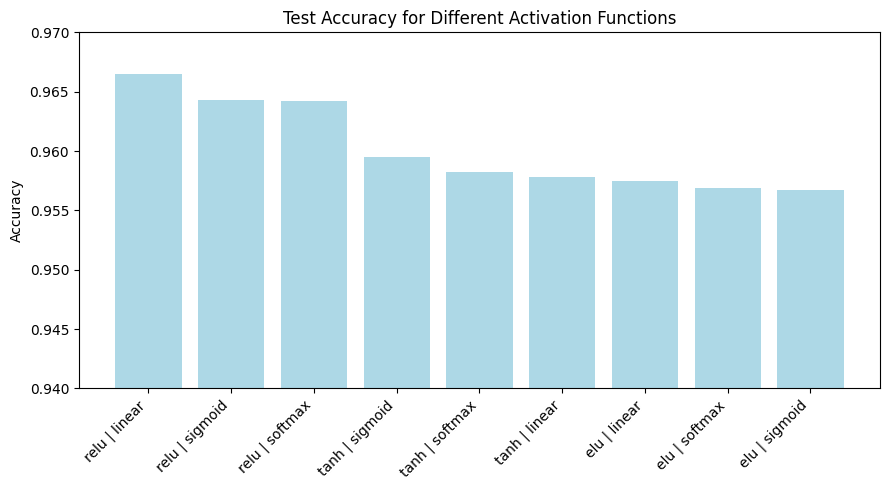

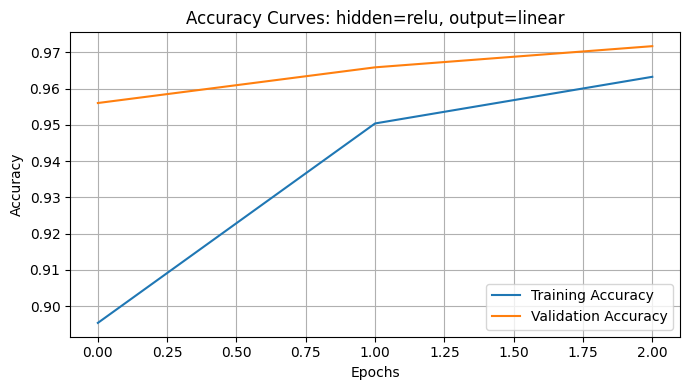

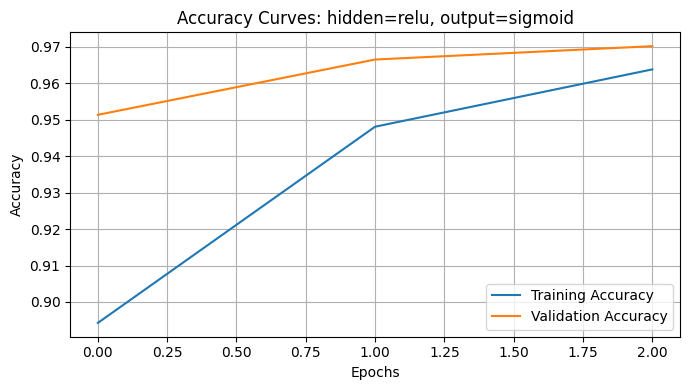

Training with regularization: None


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training with regularization: l1
Training with regularization: l2
Training with regularization: dropout

=== Regularization Results ===
  regularization  test_acc
0           none    0.9665
3        dropout    0.9629
2             l2    0.9611
1             l1    0.9304


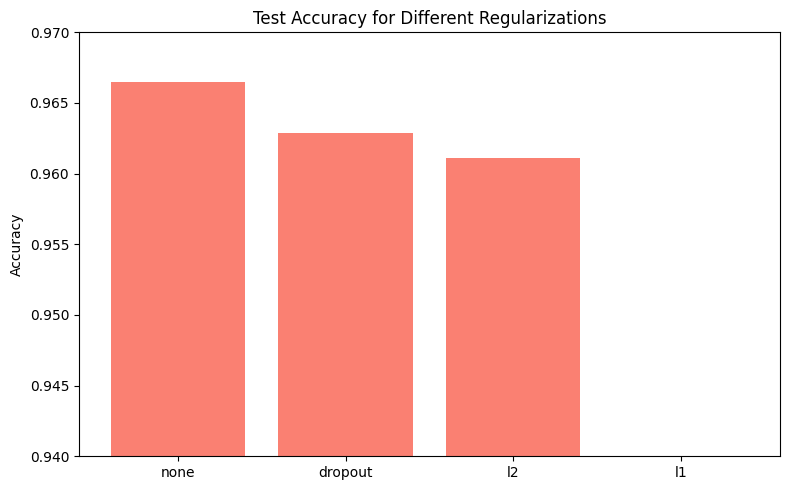

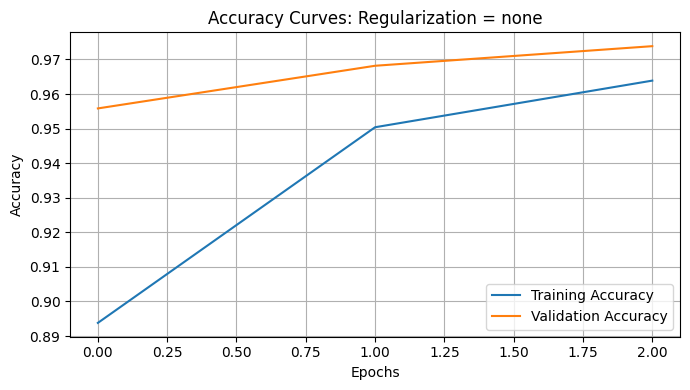

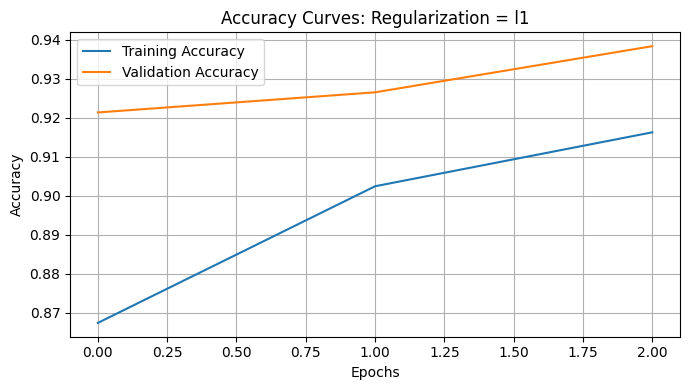

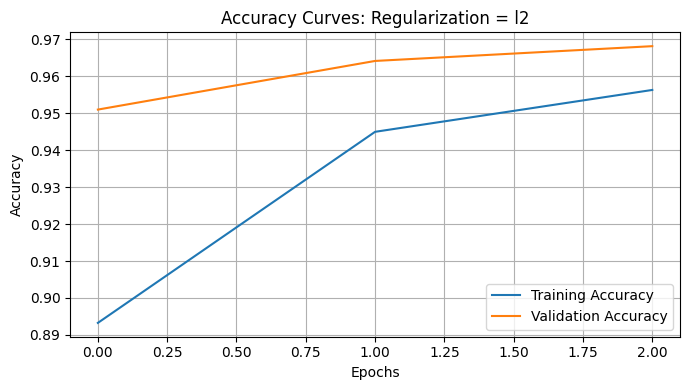

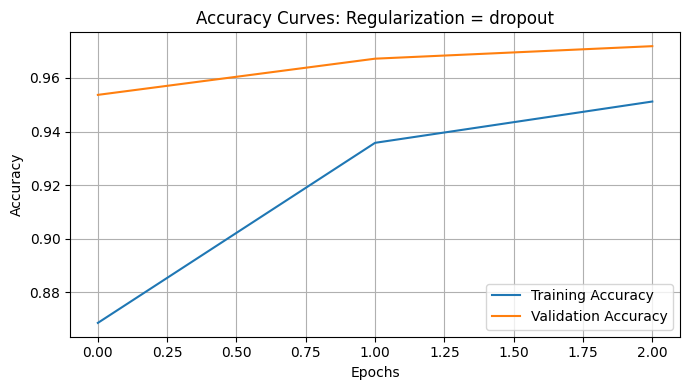

In [28]:
from tensorflow import keras
from tensorflow.keras import layers, regularizers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

num_classes = 10
y_train_1h = keras.utils.to_categorical(y_train, num_classes)
y_test_1h = keras.utils.to_categorical(y_test, num_classes)


def build_model(hidden_activation="relu",
                output_activation="softmax",
                kernel_reg=None,
                dropout_rate=None):


    # Define regularizer
    if kernel_reg == "l1":
        reg = regularizers.l1(0.001)
    elif kernel_reg == "l2":
        reg = regularizers.l2(0.001)
    else:
        reg = None

    model = keras.Sequential()
    model.add(layers.Flatten(input_shape=(28, 28)))
    model.add(layers.Dense(128, activation=hidden_activation, kernel_regularizer=reg))

    # Add dropout layer
    if dropout_rate:
        model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(10, activation=output_activation))
    return model


def compile_and_train(model, output_activation, epochs=3, batch_size=128):
    """Compile model depending on output activation and train briefly."""
    if output_activation == "softmax":
        loss = "sparse_categorical_crossentropy"
        labels_train, labels_test = y_train, y_test
    elif output_activation == "linear":
        loss = keras.losses.SparseCategoricalCrossentropy(from_logits=True)
        labels_train, labels_test = y_train, y_test
    elif output_activation == "sigmoid":
        loss = "categorical_crossentropy"
        labels_train, labels_test = y_train_1h, y_test_1h
    else:
        raise ValueError("Unsupported output activation")

    model.compile(optimizer="adam", loss=loss, metrics=["accuracy"])
    history = model.fit(x_train, labels_train, validation_split=0.1,
                        epochs=epochs, batch_size=batch_size, verbose=0)
    test_loss, test_acc = model.evaluate(x_test, labels_test, verbose=0)
    return history, test_acc


#Try different activation functions


hidden_activations = ["relu", "tanh", "elu"]
output_activations = ["softmax", "sigmoid", "linear"]

activation_results = []
activation_histories = {}

for h in hidden_activations:
    for o in output_activations:
        print(f"Training: hidden={h}, output={o}")
        model = build_model(hidden_activation=h, output_activation=o)
        history, test_acc = compile_and_train(model, o)
        activation_results.append({"hidden": h, "output": o, "test_acc": round(test_acc, 4)})
        activation_histories[(h, o)] = history.history

# Table of activation results
activation_df = pd.DataFrame(activation_results).sort_values("test_acc", ascending=False)
print("\n=== Activation Function Results ===")
print(activation_df)

# Plot bar chart for activations
plt.figure(figsize=(9,5))
plt.title("Test Accuracy for Different Activation Functions")
labels = [f"{r['hidden']} | {r['output']}" for _, r in activation_df.iterrows()]
plt.bar(labels, activation_df["test_acc"], color="lightblue")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Accuracy")
plt.ylim(0.94, 0.97)
plt.tight_layout()
plt.show()

# Plot accuracy curves for top 2 activations
top2 = activation_df.head(2)
for i in range(len(top2)):
    h, o = top2.iloc[i]["hidden"], top2.iloc[i]["output"]
    hist = activation_histories[(h, o)]
    plt.figure(figsize=(7,4))
    plt.plot(hist["accuracy"], label="Training Accuracy")
    plt.plot(hist["val_accuracy"], label="Validation Accuracy")
    plt.title(f"Accuracy Curves: hidden={h}, output={o}")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# try different regularization types

regularizers_to_try = [None, "l1", "l2", "dropout"]
regularization_results = []
regularization_histories = {}

for reg in regularizers_to_try:
    print(f"Training with regularization: {reg}")

    if reg == "dropout":
        model = build_model(hidden_activation="relu", output_activation="softmax", dropout_rate=0.3)
    else:
        model = build_model(hidden_activation="relu", output_activation="softmax", kernel_reg=reg)

    history, test_acc = compile_and_train(model, "softmax")
    regularization_results.append({"regularization": reg or "none", "test_acc": round(test_acc, 4)})
    regularization_histories[reg or "none"] = history.history

# Table of regularization results
reg_df = pd.DataFrame(regularization_results).sort_values("test_acc", ascending=False)
print("\n=== Regularization Results ===")
print(reg_df)

# Plot bar chart for regularizations
plt.figure(figsize=(8,5))
plt.title("Test Accuracy for Different Regularizations")
plt.bar(reg_df["regularization"], reg_df["test_acc"], color="salmon")
plt.ylabel("Accuracy")
plt.ylim(0.94, 0.97)
plt.tight_layout()
plt.show()

# Plot accuracy curves
for reg in regularizers_to_try:
    reg_name = reg or "none"
    hist = regularization_histories[reg_name]
    plt.figure(figsize=(7,4))
    plt.plot(hist["accuracy"], label="Training Accuracy")
    plt.plot(hist["val_accuracy"], label="Validation Accuracy")
    plt.title(f"Accuracy Curves: Regularization = {reg_name}")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [30]:
import tensorflow as tf

def build_fc_model():
    fc_model = tf.keras.Sequential([
        # First layer
        tf.keras.layers.Flatten(),

        #First dense layer (hidden layer)
        tf.keras.layers.Dense(128, activation='relu'),

        # second dense layer (output layer )
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    return fc_model


#### Compile the Two-Layer Neural Network

**TODO**

1. Try different [optimizers](https://keras.io/api/optimizers/), and report the difference in **accuracy** and plots.
2. **For each optimizer**, try different learning rates and other hyperparameters (If applicable), and report the difference in **accuracy** and plots.
3. Try different [loss functions](https://keras.io/api/losses/), and report the difference in **accuracy** and plots.

**Make sure to add the following to the report:**


*   Include the default case for the optimizer and its hyperparameters using SGD(lr = 0.1) (2.9 in the report)
*   Experiment with other combinations of optimizers and their hyperparameters (2.10, 2.11, 2.12 in the report)
*   Include the default case for the loss using cross entropy (2.13 in the report)
*   Try out two other loss functions (2.14, 2.15 in the report)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training optimizer=SGD, lr=0.1
Training optimizer=SGD, lr=0.01
Training optimizer=Adam, lr=0.001
Training optimizer=Adam, lr=0.0005
Training optimizer=RMSprop, lr=0.001
Training optimizer=RMSprop, lr=0.0005

=== Optimizers & Learning Rates: test accuracy ===
  optimizer      lr  test_acc                            plot
0      Adam  0.0010    0.9665      plots/opt_Adam_lr0.001.png
1   RMSprop  0.0010    0.9662   plots/opt_RMSprop_lr0.001.png
2   RMSprop  0.0005    0.9550  plots/opt_RMSprop_lr0.0005.png
3      Adam  0.0005    0.9493     plots/opt_Adam_lr0.0005.png
4       SGD  0.1000    0.9454         plots/opt_SGD_lr0.1.png
5       SGD  0.0100    0.8947        plots/opt_SGD_lr0.01.png
Plots saved under ./plots (filenames start with 'opt_').
Training loss=Sparse Categorical Crossentropy


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training loss=Categorical Crossentropy
Training loss=Kullback–Leibler Divergence

=== Loss functions: test accuracy ===
                              loss  test_acc  \
0  Sparse Categorical Crossentropy    0.9694   
1         Categorical Crossentropy    0.9644   
2      Kullback–Leibler Divergence    0.9628   

                                             plot  
0  plots/loss_Sparse_Categorical_Crossentropy.png  
1         plots/loss_Categorical_Crossentropy.png  
2      plots/loss_Kullback–Leibler_Divergence.png  
Plots saved under ./plots (filenames start with 'loss_').
plots/loss_Categorical_Crossentropy.png


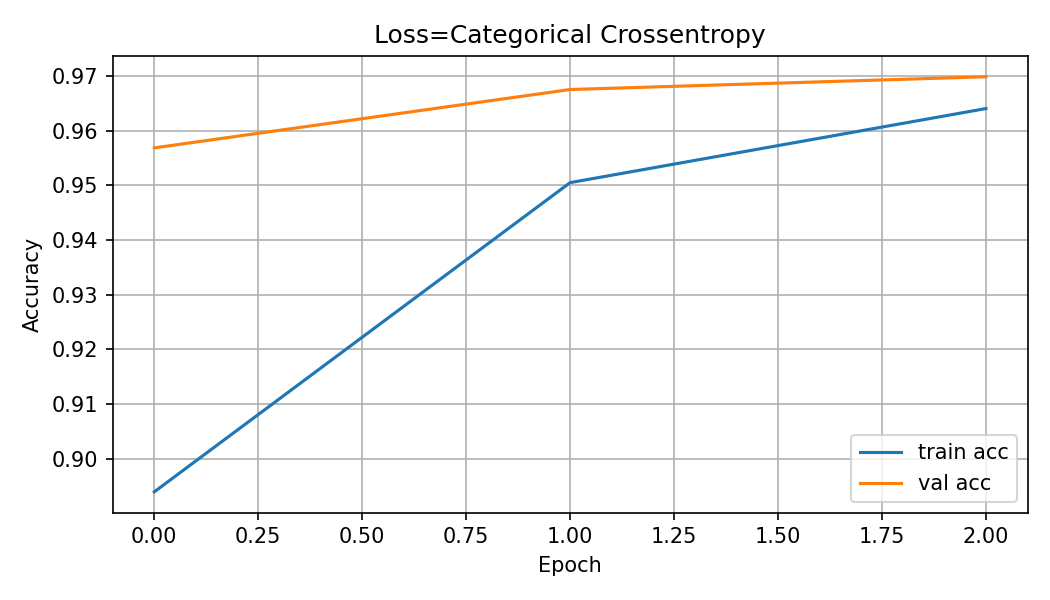

plots/loss_Kullback–Leibler_Divergence.png


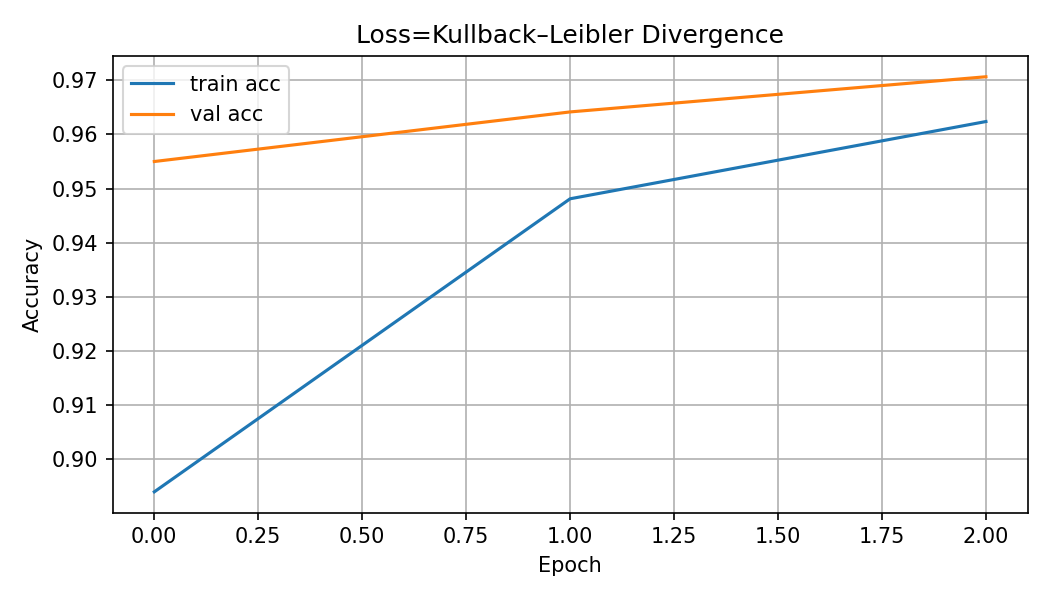

plots/loss_Sparse_Categorical_Crossentropy.png


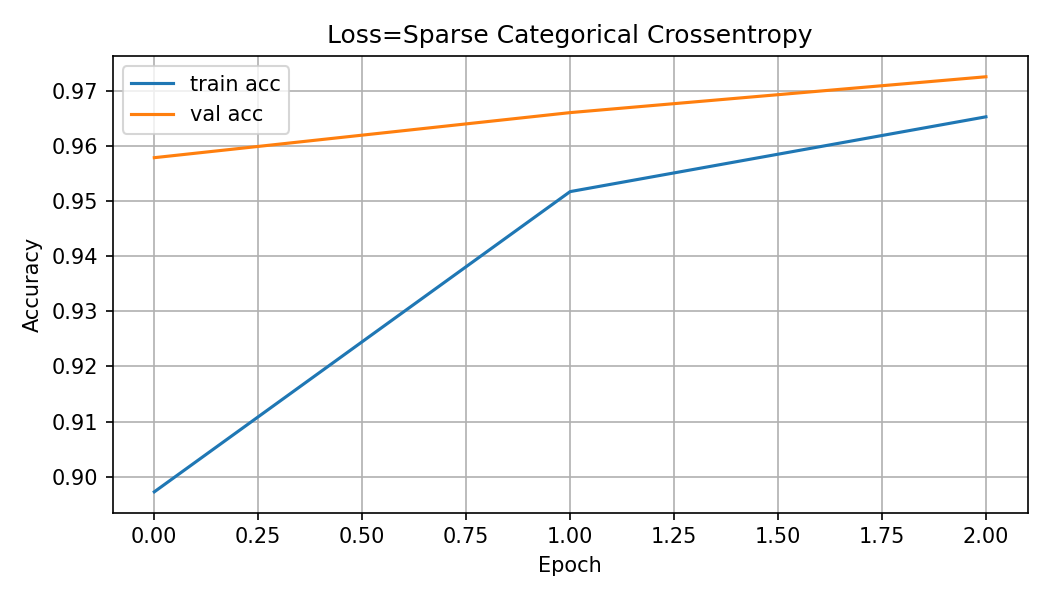

plots/opt_Adam_lr0.0005.png


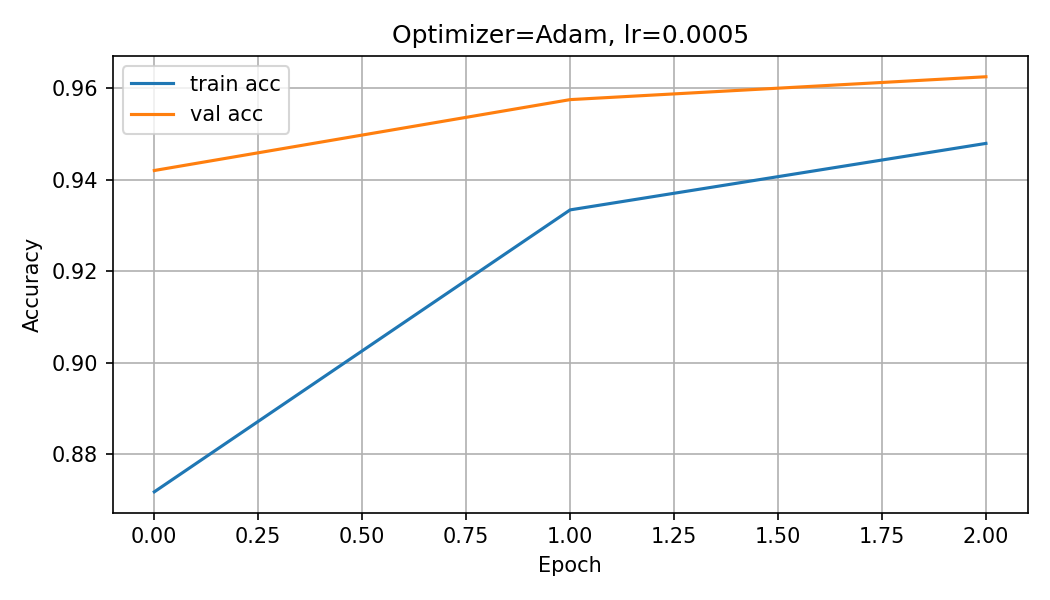

plots/opt_Adam_lr0.001.png


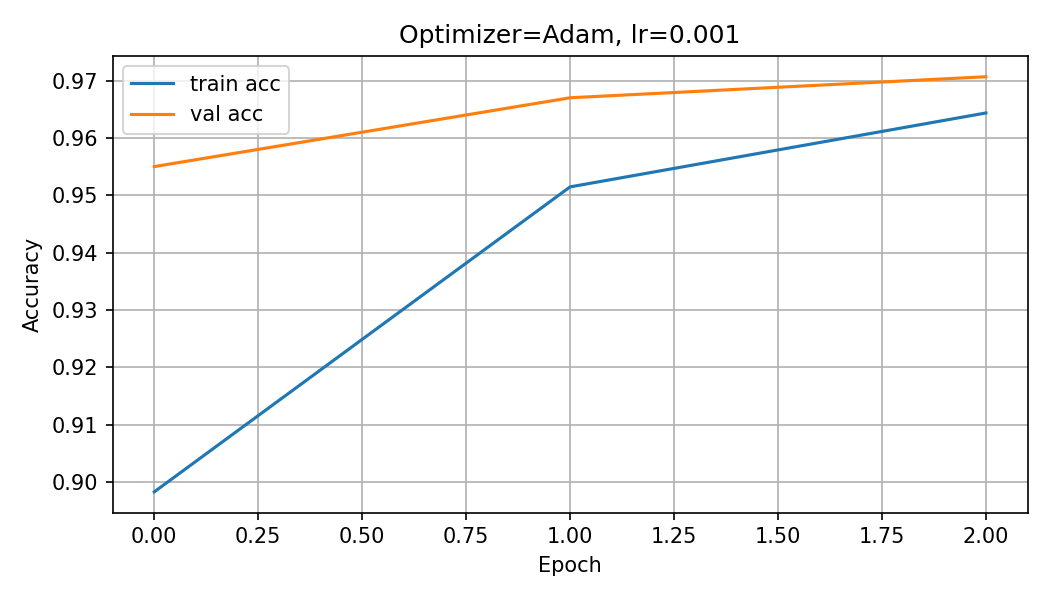

plots/opt_RMSprop_lr0.0005.png


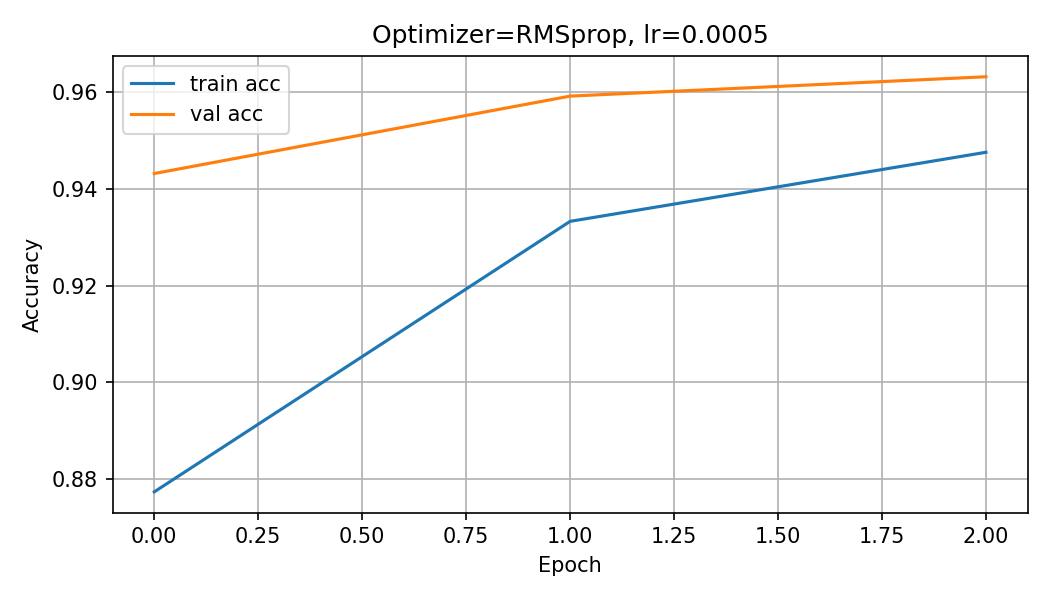

plots/opt_RMSprop_lr0.001.png


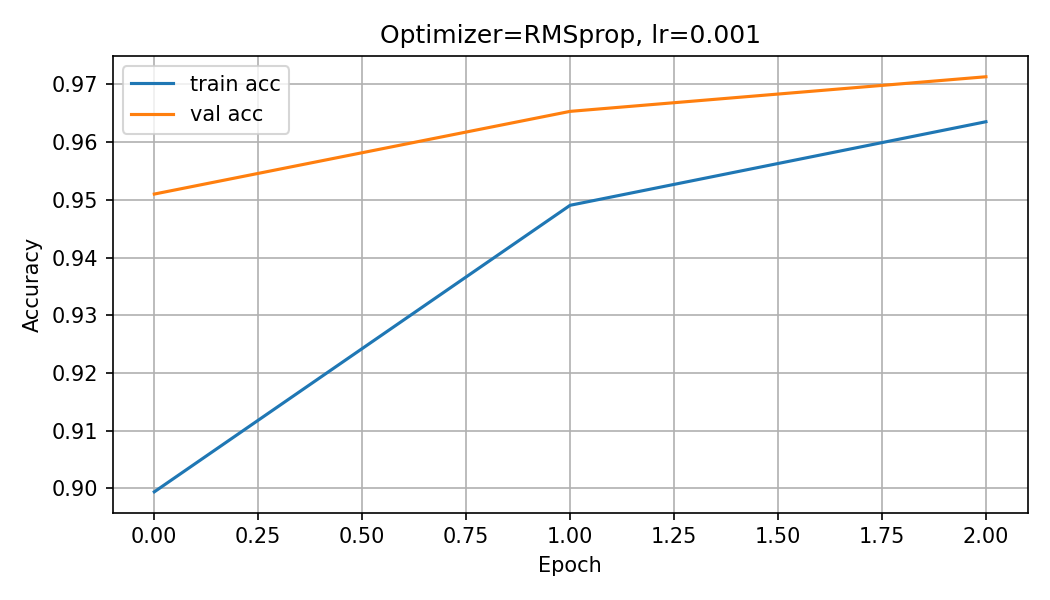

plots/opt_SGD_lr0.01.png


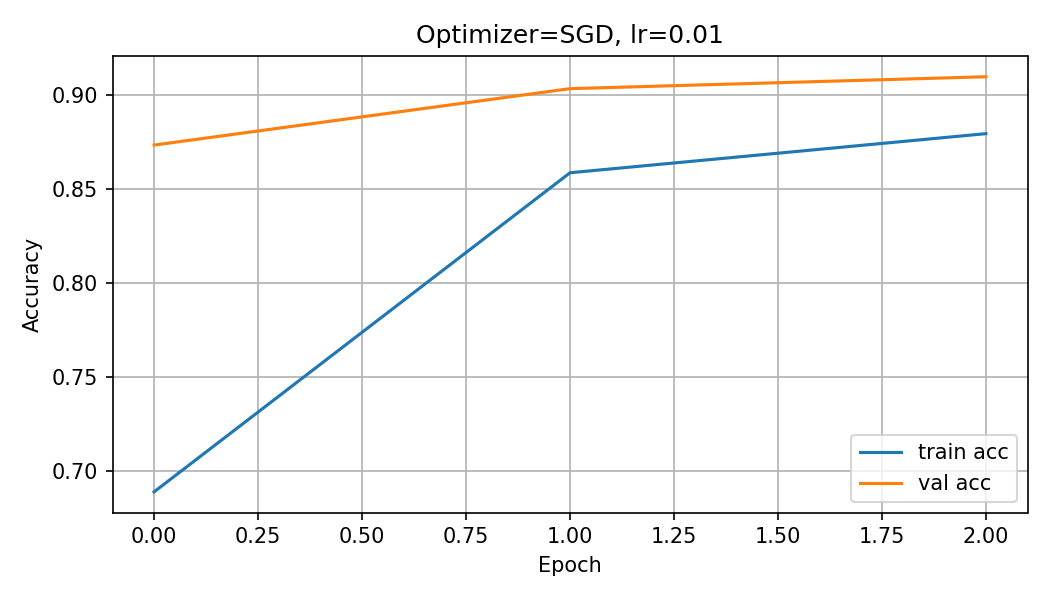

plots/opt_SGD_lr0.1.png


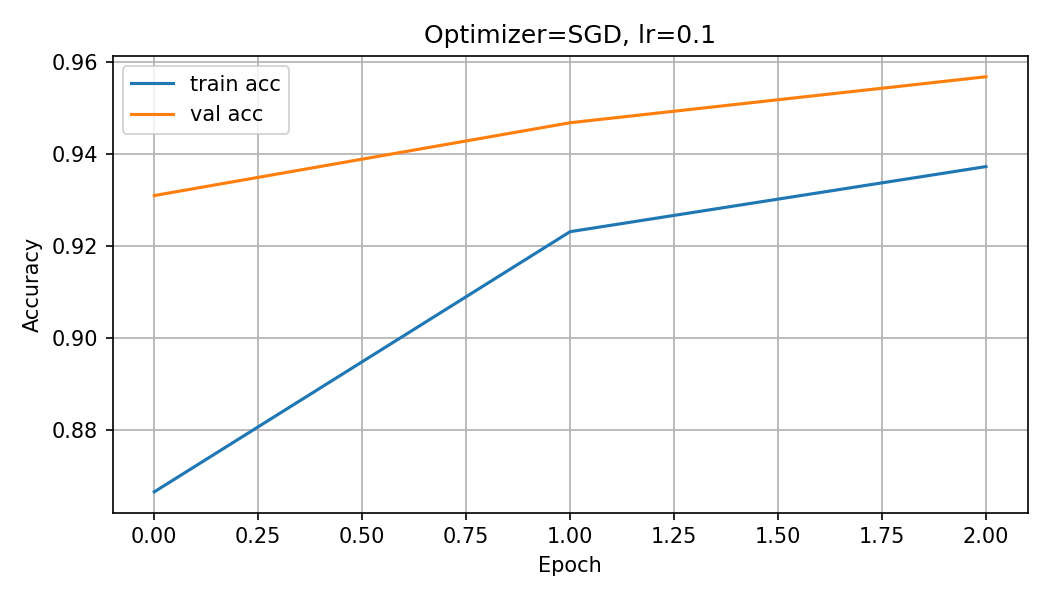

In [31]:
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

os.makedirs("plots", exist_ok=True)
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

num_classes = 10
y_train_1h = keras.utils.to_categorical(y_train, num_classes)
y_test_1h  = keras.utils.to_categorical(y_test,  num_classes)

def build_fc_model(hidden_activation="relu", output_activation="softmax"):
    return keras.Sequential([
        layers.Flatten(input_shape=(28, 28)),
        layers.Dense(128, activation=hidden_activation),
        layers.Dense(10, activation=output_activation)
    ])

def train_once(model, optimizer, loss, labels_train, labels_test, epochs=3, batch_size=128):
    model.compile(optimizer=optimizer, loss=loss, metrics=["accuracy"])
    hist = model.fit(x_train, labels_train, validation_split=0.1,
                     epochs=epochs, batch_size=batch_size, verbose=0)
    test_loss, test_acc = model.evaluate(x_test, labels_test, verbose=0)
    return hist.history, float(test_acc)

def save_curves(history, title, fname):
    plt.figure(figsize=(7,4))
    plt.plot(history["accuracy"], label="train acc")
    plt.plot(history["val_accuracy"], label="val acc")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    path = os.path.join("plots", fname)
    plt.savefig(path, dpi=150)
    plt.close()
    return path

# Optimizers + learning rates

optimizer_specs = {
    "SGD":     [0.1, 0.01],
    "Adam":    [0.001, 0.0005],

}

opt_results = []

for opt_name, lr_list in optimizer_specs.items():
    for lr in lr_list:
        model = build_fc_model("relu", "softmax")

        if opt_name == "SGD":
            optimizer = keras.optimizers.SGD(learning_rate=lr, momentum=0.0)
        elif opt_name == "Adam":
            optimizer = keras.optimizers.Adam(learning_rate=lr)
        elif opt_name == "RMSprop":
            optimizer = keras.optimizers.RMSprop(learning_rate=lr)
        else:
            raise ValueError("Unknown optimizer")

        # softmax outputs
        loss = keras.losses.SparseCategoricalCrossentropy()
        labels_train, labels_test = y_train, y_test

        print(f"Training optimizer={opt_name}, lr={lr}")
        hist, test_acc = train_once(model, optimizer, loss, labels_train, labels_test)
        plot_path = save_curves(
            hist, f"Optimizer={opt_name}, lr={lr}",
            f"opt_{opt_name}_lr{lr}.png"
        )
        opt_results.append({
            "optimizer": opt_name,
            "lr": lr,
            "test_acc": round(test_acc, 4),
            "plot": plot_path
        })

opt_df = pd.DataFrame(opt_results).sort_values("test_acc", ascending=False).reset_index(drop=True)
print("\n=== Optimizers & Learning Rates: test accuracy ===")
print(opt_df)
print("Plots saved under ./plots (filenames start with 'opt_').")

# Loss functions


loss_specs = [
    ("Sparse Categorical Crossentropy",
     keras.losses.SparseCategoricalCrossentropy(), "sparse"),

    ("Categorical Crossentropy",
     keras.losses.CategoricalCrossentropy(), "onehot"),

    ("Kullback–Leibler Divergence",
     keras.losses.KLDivergence(), "onehot"),
]

loss_results = []

for lname, lobj, label_kind in loss_specs:
    model = build_fc_model("relu", "softmax")
    optimizer = keras.optimizers.Adam(learning_rate=1e-3)

    if label_kind == "sparse":
        labels_train, labels_test = y_train, y_test
    else:
        labels_train, labels_test = y_train_1h, y_test_1h

    print(f"Training loss={lname}")
    hist, test_acc = train_once(model, optimizer, lobj, labels_train, labels_test)
    plot_path = save_curves(
        hist, f"Loss={lname}",
        f"loss_{lname.replace(' ','_')}.png"
    )
    loss_results.append({
        "loss": lname,
        "test_acc": round(test_acc, 4),
        "plot": plot_path
    })

loss_df = pd.DataFrame(loss_results).sort_values("test_acc", ascending=False).reset_index(drop=True)
print("\n=== Loss functions: test accuracy ===")
print(loss_df)
print("Plots saved under ./plots (filenames start with 'loss_').")



from IPython.display import display, Image
import glob

for img_path in sorted(glob.glob("plots/*.png")):
    print(img_path)
    display(Image(filename=img_path))




In [32]:
fc_model = build_fc_model()

'''TODO: Experiment with different optimizers and learning rates. Think about how do these affect
    the accuracy of the trained model? Which optimizers and/or learning rates yield
    the best performance?'''
fc_model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=1e-1),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [33]:
# Try different optimizers and learning rates

optimizers_to_try = {
    "SGD":     [1e-1, 1e-2, 5e-3],
    "Adam":    [1e-3, 5e-4],
}

def make_optimizer(name, lr):
    if name == "SGD":
        return tf.keras.optimizers.SGD(learning_rate=lr, momentum=0.0)
    if name == "Adam":
        return tf.keras.optimizers.Adam(learning_rate=lr)
    if name == "RMSprop":
        return tf.keras.optimizers.RMSprop(learning_rate=lr)
    raise ValueError("Unknown optimizer")

results = []

for opt_name, lr_list in optimizers_to_try.items():
    for lr in lr_list:
        model = build_fc_model()
        model.compile(
            optimizer=make_optimizer(opt_name, lr),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
        hist = model.fit(
            x_train, y_train,
            validation_split=0.1,
            epochs=3, batch_size=128, verbose=0
        )
        test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
        val_acc = float(hist.history["val_accuracy"][-1])

        results.append({
            "optimizer": opt_name,
            "lr": lr,
            "val_acc": val_acc,
            "test_acc": float(test_acc)
        })
        print(f"{opt_name:7s} | lr={lr:.4g} -> val_acc={val_acc:.4f}, test_acc={test_acc:.4f}")

#best combo
best = max(results, key=lambda r: r["test_acc"])
print("\nBest combo:",
      f"{best['optimizer']} with lr={best['lr']:.4g} | test_acc={best['test_acc']:.4f}")


SGD     | lr=0.1 -> val_acc=0.9548, test_acc=0.9431
SGD     | lr=0.01 -> val_acc=0.9125, test_acc=0.8951
SGD     | lr=0.005 -> val_acc=0.8885, test_acc=0.8678
Adam    | lr=0.001 -> val_acc=0.9707, test_acc=0.9658
Adam    | lr=0.0005 -> val_acc=0.9633, test_acc=0.9528
RMSprop | lr=0.001 -> val_acc=0.9715, test_acc=0.9678
RMSprop | lr=0.0005 -> val_acc=0.9628, test_acc=0.9541

Best combo: RMSprop with lr=0.001 | test_acc=0.9678


#### Print the Two-Layer Neural Network Model Summary

In [57]:
fc_model.build((None, train_images.shape[1], train_images.shape[2], train_images.shape[3]))
fc_model.summary()

ValueError: Sequential model 'sequential_61' has already been configured to use input shape (None, 28, 28). You cannot build it with input_shape (None, 28, 28, 1)

#### Train the Two-Layer Neural Network

In [35]:
BATCH_SIZE = 64
EPOCHS = 10

nn_hist = fc_model.fit(train_images, train_labels, validation_data=(val_images, val_labels), batch_size=BATCH_SIZE, epochs=EPOCHS)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8356 - loss: 0.5999 - val_accuracy: 0.9359 - val_loss: 0.2282
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9373 - loss: 0.2184 - val_accuracy: 0.9522 - val_loss: 0.1639
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9554 - loss: 0.1558 - val_accuracy: 0.9555 - val_loss: 0.1491
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9628 - loss: 0.1263 - val_accuracy: 0.9675 - val_loss: 0.1154
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9704 - loss: 0.1017 - val_accuracy: 0.9691 - val_loss: 0.1070
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9755 - loss: 0.0866 - val_accuracy: 0.9722 - val_loss: 0.0970
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9770 - loss: 0.0799 - val_accuracy: 0.9726 - val_loss: 0.0911
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9809 - loss: 0.0681 - val_accuracy: 0.

#### Plot the Accuracy Curve for the Two-Layer Neural Network

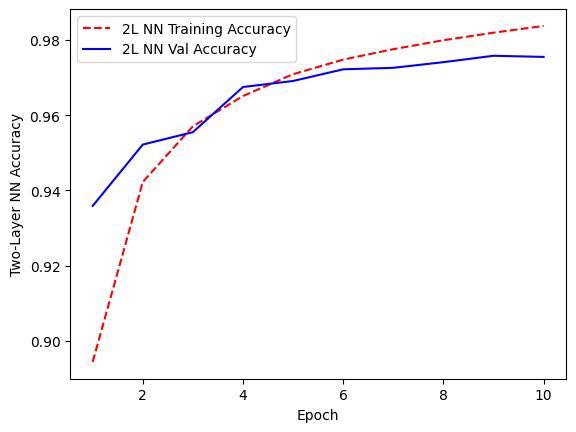

In [36]:
# Get training and validation accuracy histories
training_acc = nn_hist.history['accuracy']
val_acc = nn_hist.history['val_accuracy']

# Create count of the number of epochs
epoch_count = range(1, EPOCHS + 1)

# Visualize accuracy history
plt.figure()
plt.plot(epoch_count, training_acc, 'r--')
plt.plot(epoch_count, val_acc, 'b-')
plt.legend(['2L NN Training Accuracy', '2L NN Val Accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Two-Layer NN Accuracy')
plt.show()

#### Evaluate the Two-Layer Neural Network

In [37]:
val_loss, val_acc = fc_model.evaluate(val_images, val_labels)

print('Validation Accuracy:', val_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9701 - loss: 0.0979
Validation Accuracy: 0.9754999876022339


### 1.2.3 Convolutional Neural Network Solution

**IMPORTANT NOTE:** You have to change runtime type on Google Colab to GPU when training the model of this part since CNN models require much computation resources and it will run very slowly on CPU (Default runtime type)

Click on "Runtime" => "Change runtime type" => make sure that GPU is selected in the "Hardware accelerator"

Build a CNN, using tf.keras, composed of two convolutional layers and pooling layers, followed by two fully connected layers, and ultimately output a probability distribution over the 10 digit classes (0-9).

![CNN Model](https://github.com/KhaledElTahan/DeepLearning/blob/master/Labs/lab2/cnn_model.png?raw=1)

#### Define the Convolutional Neural Network

**TODO**

1. Define the convolutional network exactly as in the previous figure by adding [Conv2D layers](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Conv2D), [MaxPool2D layers](https://www.tensorflow.org/api_docs/python/tf/keras/layers/MaxPool2D), [flatten layer](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Flatten), and [dense layers](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dense)
2. Try different [activation functions](https://keras.io/api/layers/#layer-activations) for the layers (ReLU, Tanh, and other activations for hidden layers - Softmax, and other activations for output layer), and report the difference in **accuracy** and plots.
3. Try different [regularization kernerls](https://keras.io/api/layers/#layer-weight-regularizers), and [regularization layers](https://keras.io/api/layers/#regularization-layers) (L1, L2, Dropout, and other regularizations), and report the difference in **accuracy** and plots.
4. Try different [convolution filter sizes](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Conv2D), and report the difference in accuracy and plots.
5. **For each convolution filter size**, try different stride lengths, and report the difference in accuracy and plots.
6. Try different [pooling layers](https://keras.io/api/layers/pooling_layers/) (i.e. change first and second pooling layers into other different pooling layers), and report the difference in accuracy and plots.

**NOTE: Variations for the filter sizes, stride lengths and pooling layers, will mean of course that you will have to use different number of units for the next layers (i.e. you won't stick to the above mentioned figure once you try those variations).**

**Make sure to add the following to the report:**


*   Include the default cases for the activation function of the hidden layers using ReLU (3.1 in the report)
*   Try out one different activation functions for the hidden layers and include it (3.2 in the report)
*   Include the default case for the activation function of the output layer using Softmax (3.3 in the report)
*   Try out another activation function for the output layer (3.4 in the report)
*   Include the default case where no regularization is added (3.5 in the report)
*   Experiment with two different regularization approaches (3.6 and 3.7 in the report)
*   Include the default case where the filter size is 3x3 and the stride length is 1 (3.8 in the report)
*   Experiment with other combinations of filter sizes and stride lengths (3.9, 3.10, 3.11, 3.12 in the report)
*   Include the default case where two max pool layers are used (3.13 in the report)
*   Experiment with other combinations of pooling layers (3.14, 3.15 in the report)



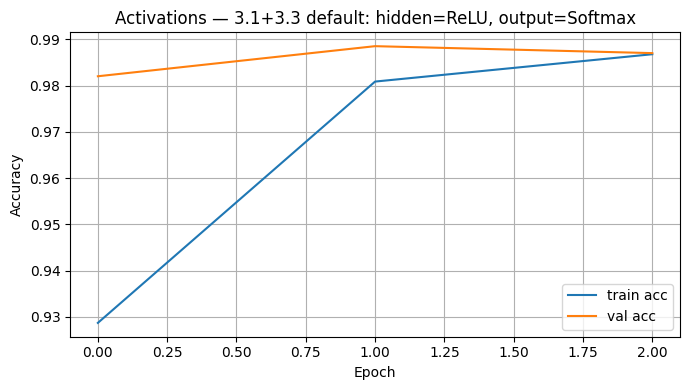

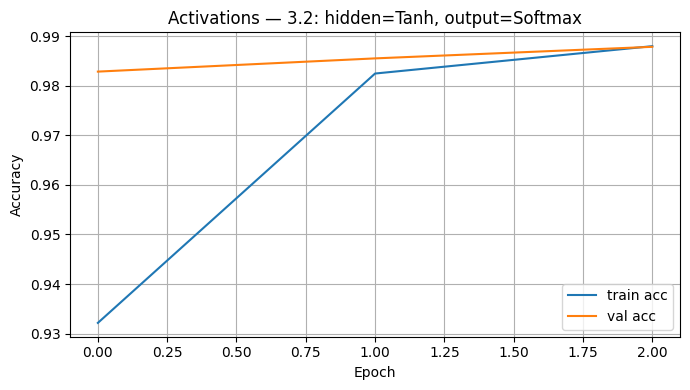

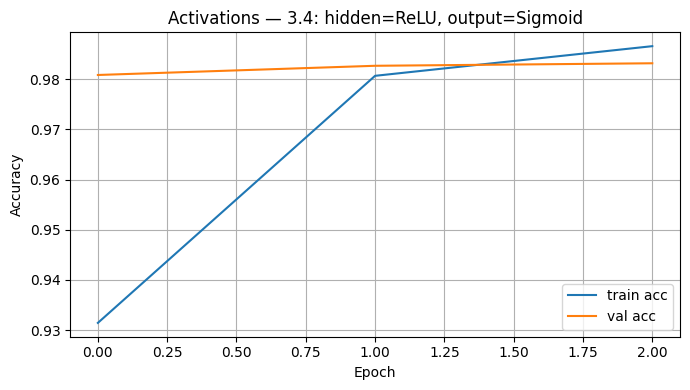


=== Activation Results (3.1–3.4) ===
  hidden_act output_act  test_acc                                       plot
0       tanh    softmax    0.9876  cnn_plots/act_hidden-tanh_out-softmax.png
1       relu    softmax    0.9871  cnn_plots/act_hidden-relu_out-softmax.png
2       relu    sigmoid    0.9815  cnn_plots/act_hidden-relu_out-sigmoid.png


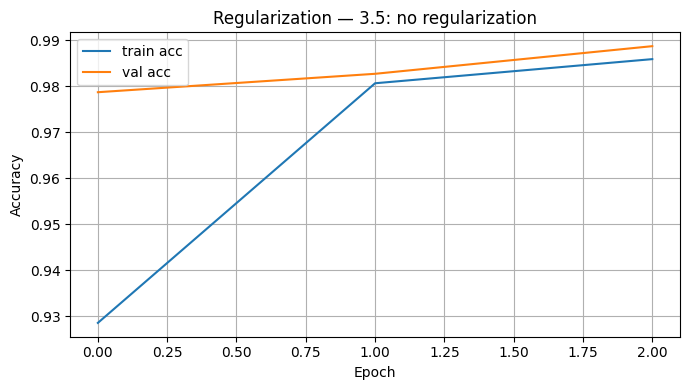

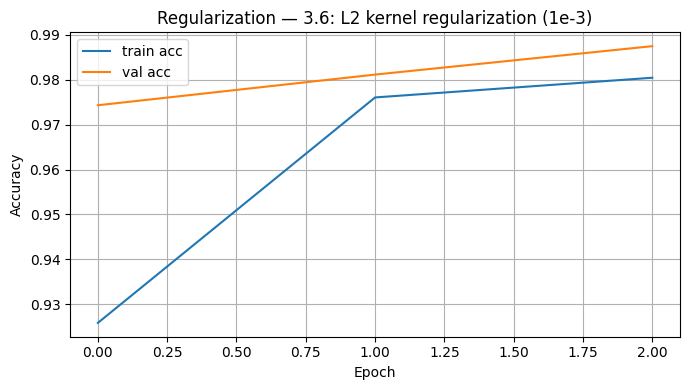

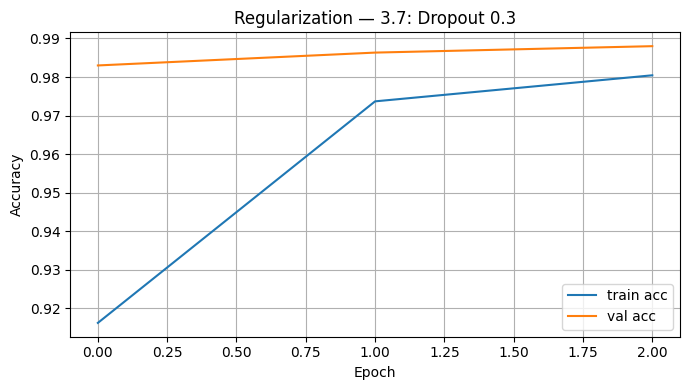


=== Regularization Results (3.5–3.7) ===
  kernel_reg  dropout  test_acc                            plot
0       none      0.3    0.9882  cnn_plots/reg_none_drop0.3.png
1       none      0.0    0.9869   cnn_plots/reg_none_nodrop.png
2         l2      0.0    0.9845     cnn_plots/reg_l2_nodrop.png


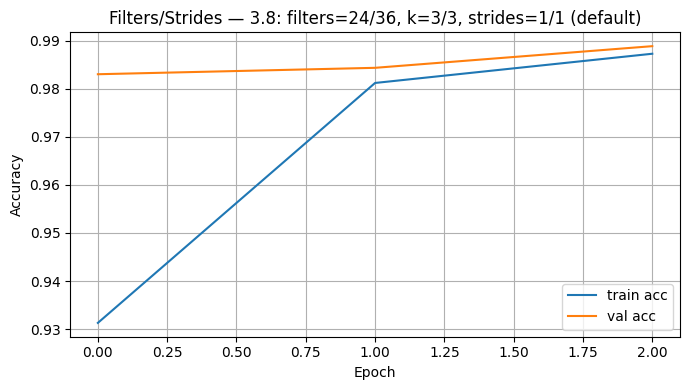

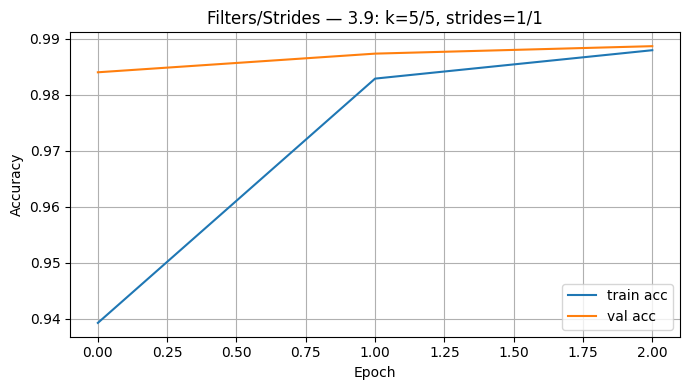

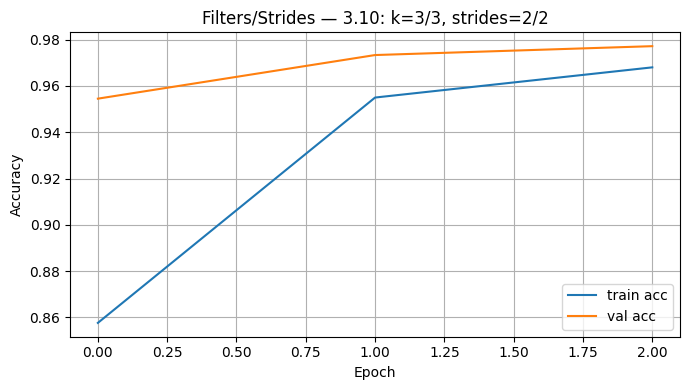

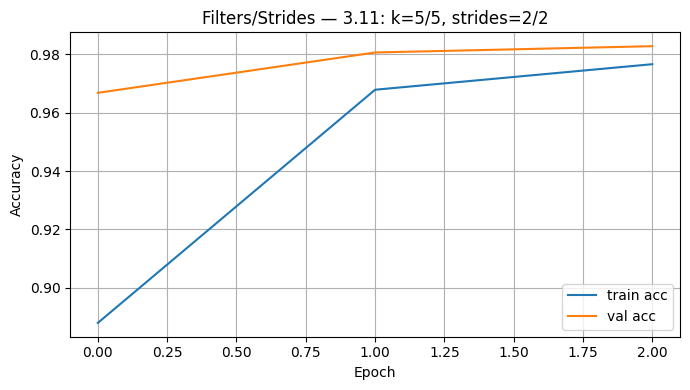

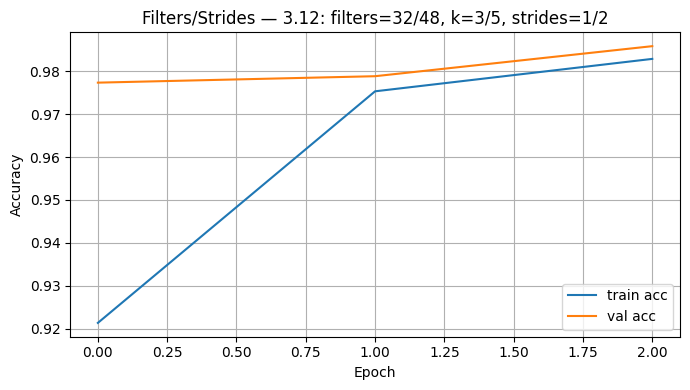


=== Filter Size & Stride Results (3.8–3.12) ===
    filters kernels strides  test_acc                               plot
0  (24, 36)  (5, 5)  (1, 1)    0.9903  cnn_plots/fs_f24-36_k5-5_s1-1.png
1  (24, 36)  (3, 3)  (1, 1)    0.9857  cnn_plots/fs_f24-36_k3-3_s1-1.png
2  (32, 48)  (3, 5)  (1, 2)    0.9849  cnn_plots/fs_f32-48_k3-5_s1-2.png
3  (24, 36)  (5, 5)  (2, 2)    0.9819  cnn_plots/fs_f24-36_k5-5_s2-2.png
4  (24, 36)  (3, 3)  (2, 2)    0.9707  cnn_plots/fs_f24-36_k3-3_s2-2.png


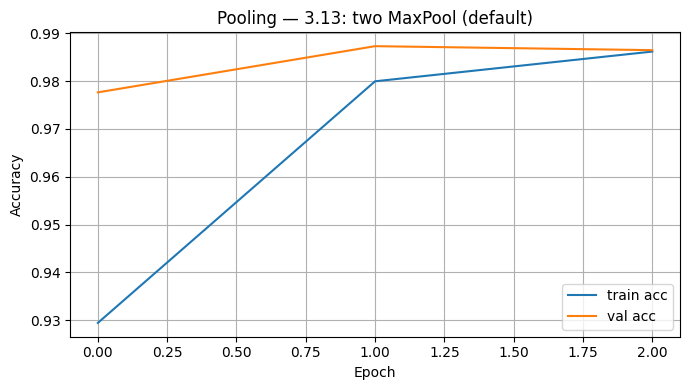

KeyboardInterrupt: 

In [38]:
from tensorflow import keras
from tensorflow.keras import layers, regularizers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

os.makedirs("cnn_plots", exist_ok=True)

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

x_train = np.expand_dims(x_train, -1)
x_test  = np.expand_dims(x_test, -1)

num_classes = 10
y_train_1h = keras.utils.to_categorical(y_train, num_classes)
y_test_1h  = keras.utils.to_categorical(y_test,  num_classes)

def build_cnn(
    hidden_activation="relu",
    output_activation="softmax",
    kernel_reg=None,
    dropout_rate=None,
    filters=(24, 36),
    kernel_sizes=(3, 3),
    strides=(1, 1),
    pooling=("max", "max"),
    pool_size=(2, 2),
    pool_strides=(2, 2)
):
    # regularizer
    if kernel_reg == "l1":
        reg = regularizers.l1(1e-3)
    elif kernel_reg == "l2":
        reg = regularizers.l2(1e-3)
    else:
        reg = None

    #  pooling types
    Pool1 = layers.MaxPooling2D if pooling[0] == "max" else layers.AveragePooling2D
    Pool2 = layers.MaxPooling2D if pooling[1] == "max" else layers.AveragePooling2D

    inp = keras.Input(shape=(28, 28, 1))

    x = layers.Conv2D(filters[0], kernel_sizes[0], strides=strides[0],
                      activation=hidden_activation, padding="same",
                      kernel_regularizer=reg)(inp)

    x = Pool1(pool_size=pool_size, strides=pool_strides, padding="same")(x)

    x = layers.Conv2D(filters[1], kernel_sizes[1], strides=strides[1],
                      activation=hidden_activation, padding="same",
                      kernel_regularizer=reg)(x)
    x = Pool2(pool_size=pool_size, strides=pool_strides, padding="same")(x)

    x = layers.Flatten()(x)
    x = layers.Dense(128, activation=hidden_activation, kernel_regularizer=reg)(x)
    if dropout_rate:
        x = layers.Dropout(dropout_rate)(x)
    out = layers.Dense(10, activation=output_activation)(x)

    return keras.Model(inp, out)

def compile_and_train(model, output_activation, epochs=3, batch_size=128):
    """Pick correct loss based on output activation and train briefly."""
    if output_activation == "softmax":
        loss  = keras.losses.SparseCategoricalCrossentropy()
        y_trn, y_tst = y_train, y_test
    elif output_activation == "linear":
        loss  = keras.losses.SparseCategoricalCrossentropy(from_logits=True)
        y_trn, y_tst = y_train, y_test
    elif output_activation == "sigmoid":
        loss  = keras.losses.CategoricalCrossentropy()
        y_trn, y_tst = y_train_1h, y_test_1h
    else:
        raise ValueError("Unsupported output activation.")

    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss=loss, metrics=["accuracy"])
    hist = model.fit(x_train, y_trn, validation_split=0.1,
                     epochs=epochs, batch_size=batch_size, verbose=0)
    test_loss, test_acc = model.evaluate(x_test, y_tst, verbose=0)
    return hist.history, float(test_acc)

def show_and_save(history, title, fname):
    plt.figure(figsize=(7,4))
    plt.plot(history["accuracy"], label="train acc")
    plt.plot(history["val_accuracy"], label="val acc")
    plt.title(title)
    plt.xlabel("Epoch"); plt.ylabel("Accuracy")
    plt.legend(); plt.grid(True); plt.tight_layout()
    path = os.path.join("cnn_plots", fname)
    plt.savefig(path, dpi=150)
    plt.show()
    return path

# Activations
act_experiments = [

    ("relu", "softmax",  "3.1+3.3 default: hidden=ReLU, output=Softmax"),
    ("tanh", "softmax",  "3.2: hidden=Tanh, output=Softmax"),
    ("relu", "sigmoid",  "3.4: hidden=ReLU, output=Sigmoid"),
]

act_results = []
for h_act, o_act, label in act_experiments:
    model = build_cnn(hidden_activation=h_act, output_activation=o_act)
    hist, acc = compile_and_train(model, o_act)
    path = show_and_save(hist, f"Activations — {label}",
                         f"act_hidden-{h_act}_out-{o_act}.png")
    act_results.append({"hidden_act": h_act, "output_act": o_act,
                        "test_acc": round(acc, 4), "plot": path})

act_df = pd.DataFrame(act_results).sort_values("test_acc", ascending=False).reset_index(drop=True)
print("\n=== Activation Results (3.1–3.4) ===")
print(act_df)

#Regularization
reg_experiments = [
    (None,   None,  "3.5: no regularization"),
    ("l2",   None,  "3.6: L2 kernel regularization (1e-3)"),
    (None,   0.3,   "3.7: Dropout 0.3"),
]

reg_results = []
for ker_reg, dr, label in reg_experiments:
    model = build_cnn(kernel_reg=ker_reg, dropout_rate=dr)
    hist, acc = compile_and_train(model, "softmax")
    path = show_and_save(hist, f"Regularization — {label}",
                         f"reg_{('none' if ker_reg is None else ker_reg)}_{('drop'+str(dr) if dr else 'nodrop')}.png")
    reg_results.append({"kernel_reg": ker_reg or "none",
                        "dropout": dr or 0.0,
                        "test_acc": round(acc, 4),
                        "plot": path})

reg_df = pd.DataFrame(reg_results).sort_values("test_acc", ascending=False).reset_index(drop=True)
print("\n=== Regularization Results (3.5–3.7) ===")
print(reg_df)

# Filter sizes & strides
fs_experiments = [
    ((24,36), (3,3), (1,1), "3.8: filters=24/36, k=3/3, strides=1/1 (default)"),
    ((24,36), (5,5), (1,1), "3.9: k=5/5, strides=1/1"),
    ((24,36), (3,3), (2,2), "3.10: k=3/3, strides=2/2"),
    ((24,36), (5,5), (2,2), "3.11: k=5/5, strides=2/2"),
    ((32,48), (3,5), (1,2), "3.12: filters=32/48, k=3/5, strides=1/2"),
]

fs_results = []
for filt, ks, st, label in fs_experiments:
    model = build_cnn(filters=filt, kernel_sizes=ks, strides=st)
    hist, acc = compile_and_train(model, "softmax")
    path = show_and_save(hist,
                         f"Filters/Strides — {label}",
                         f"fs_f{filt[0]}-{filt[1]}_k{ks[0]}-{ks[1]}_s{st[0]}-{st[1]}.png")
    fs_results.append({"filters": f"{filt}",
                       "kernels": f"{ks}",
                       "strides": f"{st}",
                       "test_acc": round(acc, 4),
                       "plot": path})

fs_df = pd.DataFrame(fs_results).sort_values("test_acc", ascending=False).reset_index(drop=True)
print("\n=== Filter Size & Stride Results (3.8–3.12) ===")
print(fs_df)

#  Pooling variants
pool_experiments = [
    (("max","max"), "3.13: two MaxPool (default)"),
    (("avg","max"), "3.14: AvgPool then MaxPool"),
    (("max","avg"), "3.15: MaxPool then AvgPool"),
]

pool_results = []
for pools, label in pool_experiments:
    model = build_cnn(pooling=pools)
    hist, acc = compile_and_train(model, "softmax")
    path = show_and_save(hist, f"Pooling — {label}",
                         f"pool_{pools[0]}-{pools[1]}.png")
    pool_results.append({"pooling": f"{pools}",
                         "test_acc": round(acc, 4),
                         "plot": path})

pool_df = pd.DataFrame(pool_results).sort_values("test_acc", ascending=False).reset_index(drop=True)
print("\n=== Pooling Results (3.13–3.15) ===")
print(pool_df)

print("\nAll plots saved under ./cnn_plots — insert them into the corresponding rows in your report.")


In [ ]:
def build_cnn_model():
    cnn_model = tf.keras.Sequential([

        #'''TODO: Define the dimensions of the first convolutional layer according to the figure: Replace the _'''
        tf.keras.layers.Conv2D(filters=_ , kernel_size=(_,_), input_shape=(28,28,1), activation=tf.nn.relu),

        #'''TODO: Define the pool size of the first max pooling layer according to the figure: Replace the _'''
        tf.keras.layers.MaxPool2D(pool_size=(_,_)),

        #'''TODO: Define the second convolutional layer according to the figure'''

        #'''TODO: Define the second max pooling layer according to the figure'''

        '''Note that if everything is defined correctly according to the figure up to this point,
        the flatten layer would give us the first Dense layer which contains
        the 900 hidden units (ie: no need to define a Dense layer here,
        only the flatten layer is needed)'''
        #'''TODO: Define the flatten layer'''

        #'''TODO: Define the second Dense layer according to the figure'''

        #'''TODO: Define the last Dense layer according to the figure'''
    ])
    return cnn_model

In [39]:
import tensorflow as tf

def build_cnn_model():
    cnn_model = tf.keras.Sequential([
        # 1) Conv layer: 24 filters, 3x3 kernel, input 28x28x1
        tf.keras.layers.Conv2D(filters=24, kernel_size=(3, 3),
                               input_shape=(28, 28, 1),
                               activation=tf.nn.relu),

        # 2) MaxPool: 2x2
        tf.keras.layers.MaxPool2D(pool_size=(2, 2), strides=2),

        # 3) Second Conv: 36 filters, 3x3 kernel
        tf.keras.layers.Conv2D(filters=36, kernel_size=(3, 3),
                               activation=tf.nn.relu),
        # 4) Second MaxPool: 2x2
        tf.keras.layers.MaxPool2D(pool_size=(2, 2), strides=2),

        # After conv/pool: shape becomes 5x5x36 -> Flatten gives 900 units
        tf.keras.layers.Flatten(),

        # 5) Dense with 128 hidden units
        tf.keras.layers.Dense(128, activation=tf.nn.relu),

        # 6) Output Dense: 10 classes with softmax
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    return cnn_model


#### Compile the Convolutional Neural Network

**TODO**

1. Try different [optimizers](https://keras.io/api/optimizers/), and report the difference in **accuracy** and plots.
2. **For each optimizer**, try different learning rates and other hyperparameters (If applicable), and report the difference in **accuracy** and plots.
3. Try different [loss functions](https://keras.io/api/losses/), and report the difference in **accuracy** and plots.

**Make sure to add the following to the report:**


*   Include the default case for the optimizer and its hyperparameters using SGD(lr = 0.1) (3.16 in the report)
*   Experiment with other combinations of optimizers and their hyperparameters (3.17, 3.18, 3.19 in the report)
*   Include the default case for the loss using cross entropy (3.20 in the report)
*   Try out two other loss functions (3.21, 3.22 in the report)



In [40]:
cnn_model = build_cnn_model()

'''TODO: Experiment with different optimizers and learning rates. How do these affect
    the accuracy of the trained model? Which optimizers and/or learning rates yield
    the best performance?'''
cnn_model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=1e-1),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


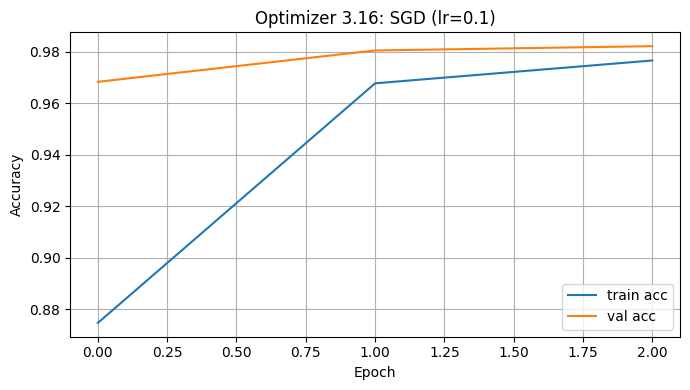

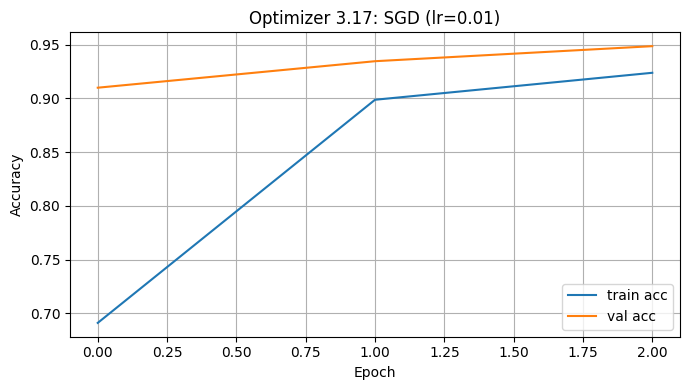

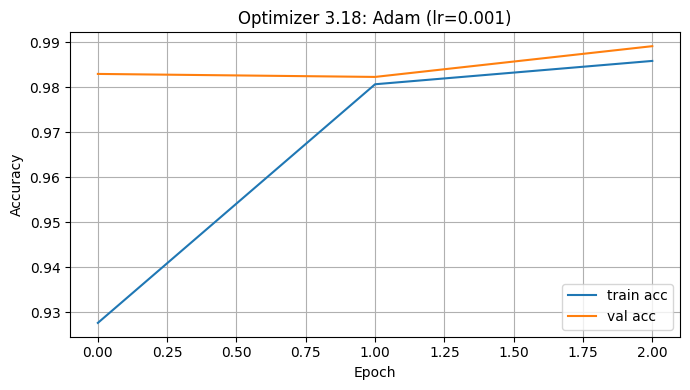

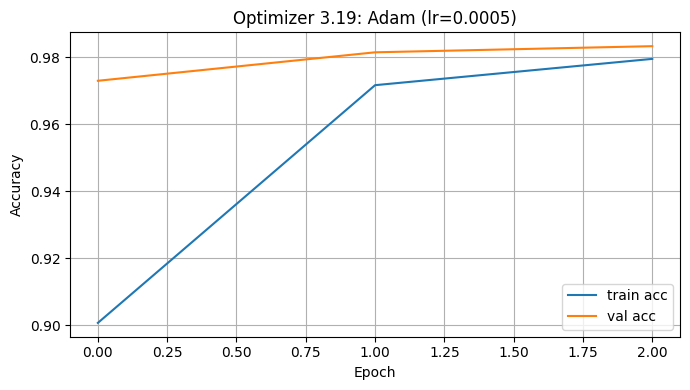


=== Optimizer (only LR changed) — Results (3.16–3.19) ===
    row         optimizer  test_acc                                     plot
0  3.16      SGD (lr=0.1)    0.9821      cnn_lr_opt_plots/3.16_SGD_lr0.1.png
1  3.17     SGD (lr=0.01)    0.9386     cnn_lr_opt_plots/3.17_SGD_lr0.01.png
2  3.18   Adam (lr=0.001)    0.9878   cnn_lr_opt_plots/3.18_Adam_lr0.001.png
3  3.19  Adam (lr=0.0005)    0.9826  cnn_lr_opt_plots/3.19_Adam_lr0.0005.png


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


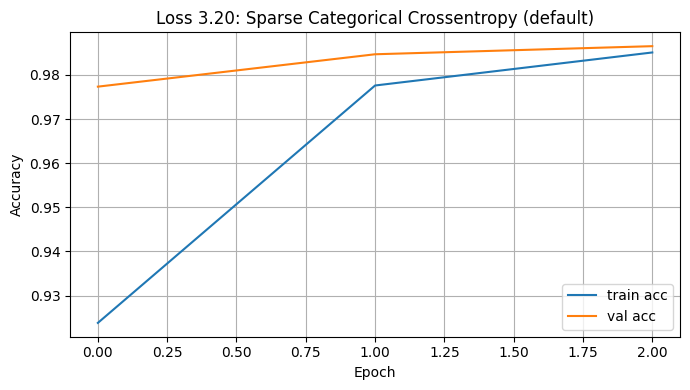

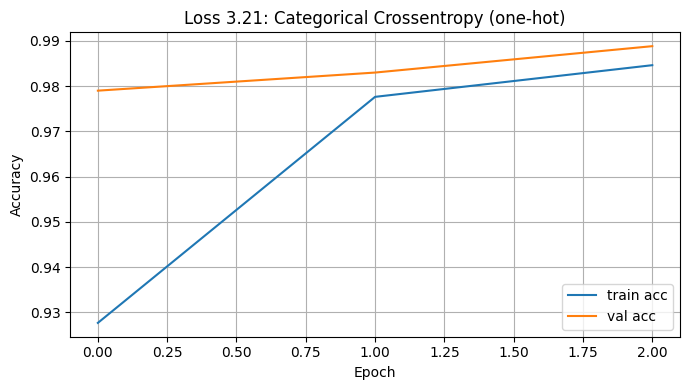

KeyboardInterrupt: 

In [41]:


import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow import keras
from tensorflow.keras import layers

os.makedirs("cnn_lr_opt_plots", exist_ok=True)
os.makedirs("cnn_lr_loss_plots", exist_ok=True)

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train = (x_train.astype("float32") / 255.0)[..., None]  # (N,28,28,1)
x_test  = (x_test.astype("float32")  / 255.0)[..., None]

num_classes = 10
y_train_1h = keras.utils.to_categorical(y_train, num_classes)
y_test_1h  = keras.utils.to_categorical(y_test,  num_classes)


def build_cnn_model():
    return keras.Sequential([
        layers.Conv2D(24, (3, 3), activation="relu", input_shape=(28, 28, 1)),
        layers.MaxPooling2D(pool_size=(2, 2), strides=2),
        layers.Conv2D(36, (3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2), strides=2),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])

def train_once(model, optimizer, loss, y_tr, y_te, epochs=3, batch_size=128):
    model.compile(optimizer=optimizer, loss=loss, metrics=["accuracy"])
    hist = model.fit(x_train, y_tr, validation_split=0.1,
                     epochs=epochs, batch_size=batch_size, verbose=0)
    test_loss, test_acc = model.evaluate(x_test, y_te, verbose=0)
    return hist.history, float(test_acc)

def plot_curves(history, title, out_path):
    plt.figure(figsize=(7,4))
    plt.plot(history["accuracy"], label="train acc")
    plt.plot(history["val_accuracy"], label="val acc")
    plt.title(title); plt.xlabel("Epoch"); plt.ylabel("Accuracy")
    plt.grid(True); plt.legend(); plt.tight_layout()
    plt.savefig(out_path, dpi=150); plt.show()

#  Optimizers
opt_grid = [
    ("3.16", "SGD",  0.1),
    ("3.17", "SGD",  0.01),
    ("3.18", "Adam", 0.001),
    ("3.19", "Adam", 0.0005),
]

opt_results = []
for tag, opt_name, lr in opt_grid:
    model = build_cnn_model()
    if opt_name == "SGD":
        optimizer = keras.optimizers.SGD(learning_rate=lr)
    elif opt_name == "Adam":
        optimizer = keras.optimizers.Adam(learning_rate=lr)
    else:
        raise ValueError("Unexpected optimizer")

    # softmax outputs
    hist, test_acc = train_once(model,
                                optimizer=optimizer,
                                loss=keras.losses.SparseCategoricalCrossentropy(),
                                y_tr=y_train, y_te=y_test)
    png = f"cnn_lr_opt_plots/{tag}_{opt_name}_lr{lr}.png"
    plot_curves(hist, f"Optimizer {tag}: {opt_name} (lr={lr})", png)
    opt_results.append({"row": tag, "optimizer": f"{opt_name} (lr={lr})",
                        "test_acc": round(test_acc, 4), "plot": png})

opt_df = pd.DataFrame(opt_results).sort_values("row").reset_index(drop=True)
print("\n=== Optimizer (only LR changed) — Results (3.16–3.19) ===")
print(opt_df)

# Loss functions (optimizer fixed)
loss_grid = [
    ("3.20", "Sparse Categorical Crossentropy (default)", keras.losses.SparseCategoricalCrossentropy(), "sparse"),
    ("3.21", "Categorical Crossentropy (one-hot)",        keras.losses.CategoricalCrossentropy(),        "onehot"),
    ("3.22", "KLDivergence (one-hot)",                    keras.losses.KLDivergence(),                   "onehot"),
]

loss_results = []
for tag, desc, loss_obj, fmt in loss_grid:
    model = build_cnn_model()
    optimizer = keras.optimizers.Adam(learning_rate=1e-3)
    y_tr, y_te = (y_train, y_test) if fmt == "sparse" else (y_train_1h, y_test_1h)

    hist, test_acc = train_once(model, optimizer=optimizer, loss=loss_obj,
                                y_tr=y_tr, y_te=y_te)
    png = f"cnn_lr_loss_plots/{tag}_{desc.split(' (')[0].replace(' ','_')}.png"
    plot_curves(hist, f"Loss {tag}: {desc}", png)
    loss_results.append({"row": tag, "loss": desc,
                         "test_acc": round(test_acc, 4), "plot": png})

loss_df = pd.DataFrame(loss_results).sort_values("row").reset_index(drop=True)
print("\n=== Loss (optimizer fixed) — Results (3.20–3.22) ===")
print(loss_df)

print("\nUse the tables above for the Accuracy column and the saved PNGs for the Plot column.")


#### Print the Convolutional Neural Network Model Summary

In [42]:
cnn_model.build((None, train_images.shape[1], train_images.shape[2], train_images.shape[3]))
cnn_model.summary()

Model: "sequential_69"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_104 (Conv2D)             │ (None, 26, 26, 24)     │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_101               │ (None, 13, 13, 24)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_105 (Conv2D)             │ (None, 11, 11, 36)     │         7,812 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_102               │ (None, 5, 5, 36)       │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_96 (Flatten)            │ (None, 900)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_192 (Dense)               │ (None, 128)            │       115,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_193 (Dense)               │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,670 (486.99 KB)

 Trainable params: 124,670 (486.99 KB)

 Non-trainable params: 0 (0.00 B)

#### Train the Convolutional Neural Network

In [43]:
BATCH_SIZE = 64
EPOCHS = 20

cnn_hist = cnn_model.fit(train_images, train_labels, validation_data=(val_images, val_labels), batch_size=BATCH_SIZE, epochs=EPOCHS)

Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8124 - loss: 0.5846 - val_accuracy: 0.9713 - val_loss: 0.0891
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9753 - loss: 0.0801 - val_accuracy: 0.9835 - val_loss: 0.0517
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9833 - loss: 0.0520 - val_accuracy: 0.9842 - val_loss: 0.0446
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9884 - loss: 0.0371 - val_accuracy: 0.9869 - val_loss: 0.0386
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9901 - loss: 0.0320 - val_accuracy: 0.9843 - val_loss: 0.0488
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9922 - loss: 0.0245 - val_accuracy: 0.9888 - val_loss: 0.0337
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9935 - loss: 0.0221 - val_accuracy: 0.9894 - val_loss: 0.0306
Epoch 8/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9940 - loss: 0.0194 - val_accuracy: 0.

#### Plot the Accuracy Curve for the Convolutional Neural Network

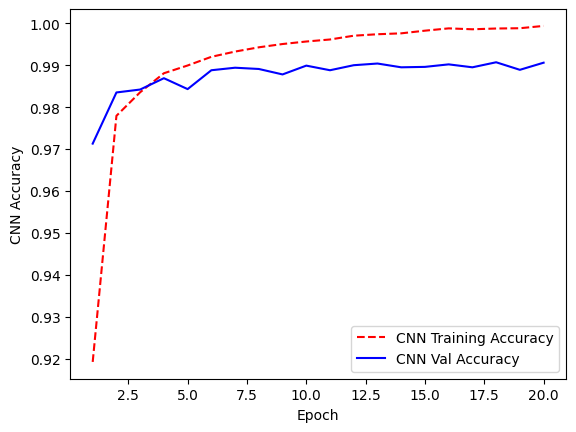

In [44]:
# training and validation accuracy histories
training_acc = cnn_hist.history['accuracy']
val_acc = cnn_hist.history['val_accuracy']

# Create count of the number of epochs
epoch_count = range(1, EPOCHS + 1)

# Visualize
plt.figure()
plt.plot(epoch_count, training_acc, 'r--')
plt.plot(epoch_count, val_acc, 'b-')
plt.legend(['CNN Training Accuracy', 'CNN Val Accuracy'])
plt.xlabel('Epoch')
plt.ylabel('CNN Accuracy')
plt.show()

#### Evaluate the Convolutional Neural Network

In [45]:
val_loss, val_acc = cnn_model.evaluate(val_images, val_labels)

print('Validation Accuracy:', val_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9876 - loss: 0.0474
Validation Accuracy: 0.9905999898910522


#### Think About the Following

**What is the highest accuracy you’re able to achieve using the CNN model, and how does the accuracy of the CNN model compare to the accuracy of the simple fully connected network?** Accordingly, answer Question 3.23 in the report

#### Machine Learning Interpretability

For this part, we will have a look at using SHAP for machine learning interpretability analysis.

A crucial part of studying machine learning models is analyzing what they are doing to make sure that the model really understands the problem and is not overfitting the data or focusing on incorrect features.

This helps us identify the model weaknesses and thus improve its performance on unseen data.

One of the ways to do so is to determine and analyze the features affecting the model's prediction. You can read more about machine learning interpretability in this [article](https://towardsdatascience.com/understanding-machine-learning-interpretability-168fd7562a1a).

[SHAP](https://shap.readthedocs.io/en/latest/overviews.html) is a technique that leverages game theory to explain the prediction by identifying the contribution of each feature on the model's final decision. You can read about other techniques in this [article](https://towardsdatascience.com/three-interpretability-methods-to-consider-when-developing-your-machine-learning-model-5bf368b47fac).

For this part, we will use the **DeepExplainer** provided by SHAP for analyzing the performance of **the best CNN model** you created on the MNIST dataset.

**You can find details about how to do so [here](https://shap.readthedocs.io/en/latest/example_notebooks/image_examples/image_classification/Front%20Page%20DeepExplainer%20MNIST%20Example.html).**

##### Installing SHAP

In [46]:
!pip install shap

##### Importing and using SHAP

In [51]:
import shap
# TODO: select a random set of background samples to take an expectation over
background = train_images['''TODO: Select a set of 1000 random images without replacement, refer to the provided link''']
# TODO: Instantiate the deep explainer with the best CNN model and the background samples
e = shap.DeepExplainer('''TODO: Fill in the correct parameters, refer to the provided link''')
# Obtaining the SHAP values on the first 10 images
shap_values = e.shap_values(val_images[1:11])

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [52]:
# plot to see where did the model concentrate to classify the images
shap.image_plot(shap_values,-val_images[1:11])

NameError: name 'shap_values' is not defined

In [55]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train = (x_train.astype("float32")/255.0)[..., None]
x_test  = (x_test.astype("float32") /255.0)[..., None]

# Build the CNN
def build_cnn_model():
    return keras.Sequential([
        layers.Conv2D(24, (3,3), activation="relu", input_shape=(28,28,1)),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(36, (3,3), activation="relu"),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])

best_cnn = build_cnn_model()
best_cnn.compile(optimizer=keras.optimizers.Adam(1e-3),
                 loss=keras.losses.SparseCategoricalCrossentropy(),
                 metrics=["accuracy"])

# train
best_cnn.fit(x_train, y_train, validation_split=0.1,
             epochs=3, batch_size=128, verbose=0)


/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_772
Received: inputs=['Tensor(shape=(1000, 28, 28, 1))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_772
Received: inputs=['Tensor(shape=(2000, 28, 28, 1))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_772
Received: inputs=['Tensor(shape=(10

<Figure size 640x480 with 0 Axes>

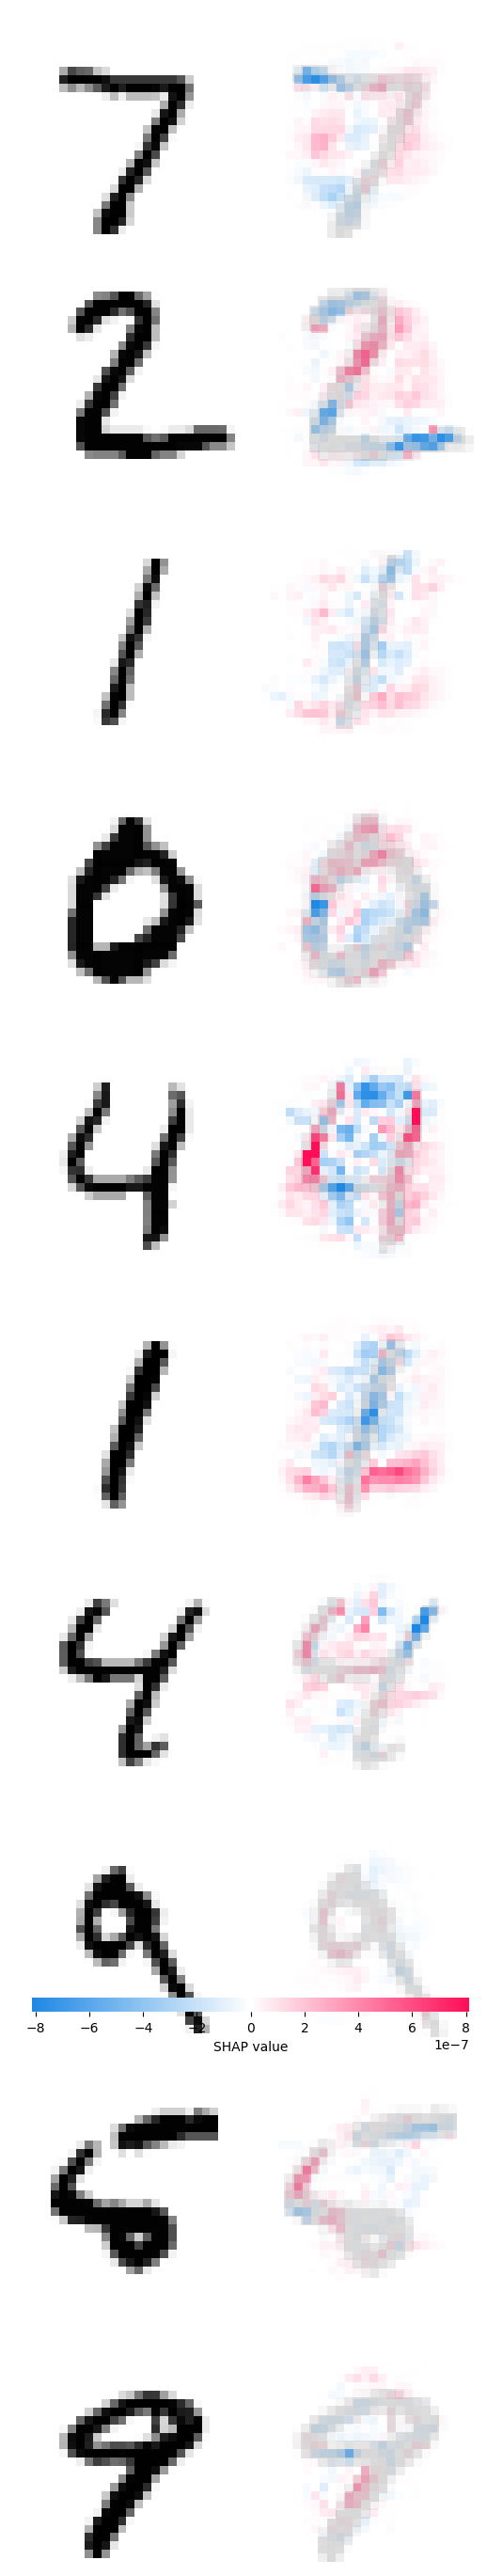

Saved SHAP plot to shap_mnist_cnn.png


In [56]:
import shap
import numpy as np
import matplotlib.pyplot as plt

#1000 random train images
np.random.seed(42)
bg_idx = np.random.choice(x_train.shape[0], 1000, replace=False)
background = x_train[bg_idx]

# first 10 test images
val_images = x_test[:10]

# Deep explainer
explainer = shap.DeepExplainer(best_cnn, background)

# SHAP values for the 10 images
shap_values = explainer.shap_values(val_images)

plt.figure()
shap.image_plot(shap_values, -val_images, show=False)  # red=for class, blue=against
plt.tight_layout()
plt.savefig("shap_mnist_cnn.png", dpi=200)
plt.show()
print("Saved SHAP plot to shap_mnist_cnn.png")


**Think about the following:**

*What does the plot show in each entry? What can you conclude from the plot? Is the model focusing on meaningful features? Why? Why not? Are there features in certain digits that confuse the model?*

***Make sure to include the SHAP plot you obtained and your comments/observations in the report for the TODOs numbered 4.2 and 4.3***

## 1.3 Conclusion

That's it! Congratulations on training multinominal classification models.

Make sure you deliver all the requirements for the submission.